# IOR Read/Write: Cold vs Warm, No-Cache Only (DFS / POSIX+IL / POSIX)

Aggregates the `ior_rw_{mode}_nocache_*.csv` files in this directory across three
access modes — **DFS** (native DAOS API), **POSIX_IL** (POSIX + interception
library on DAOS), **POSIX** (dfuse, no IL). Cache-on runs also exist on disk but
are excluded here: this notebook isolates cold vs warm iteration behavior across
engines, without the cache-state as a confound (DFS bypasses the OS page cache
entirely, so a cache/nocache split isn't meaningful for it anyway).

Write iterations are split into **cold** (`iter == 0`, first open/create) and
**warm** (`iter >= 1`, steady state); read shows no comparable split in any
engine, so it is kept as a single series (see sanity check below).

CV% = σ / μ × 100, computed across all iterations of a given **(engine,
series)** config, pooled across every repeated run file for that config.

In [1]:
import json
import re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Filename convention: `ior_rw_{mode}_n-{N}_ppn-{PPN}_tx-{TX}_{timestamp}.csv`,
where `mode` is one of `DFS_cache`, `DFS_nocache`, `POSIX_IL_cache`,
`POSIX_IL_nocache`, `POSIX_cache`, `POSIX_nocache`. `mode` is split into an
access **engine** (`DFS` / `POSIX_IL` / `POSIX`) and a **cache** flag (`cache` /
`nocache`); `n`, `ppn`, `tx`, `timestamp` are parsed from the filename too. All
files are parsed, but only `cache == "nocache"` rows are kept for the analysis
below.

In [ ]:
data_dir = Path(".")
csv_files = sorted(data_dir.glob("ior_rw_*.csv"))
print(f"Found {len(csv_files)} CSV files")

frames = []
for f in csv_files:
    m = re.search(r'^ior_rw_(DFS|POSIX_IL|POSIX)_(cache|nocache)_n-(\d+)_ppn-(\d+)_tx-(\w+)_(\d+)', f.stem)
    if not m:
        print(f"  skipping (no match): {f.name}")
        continue
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()
    df["engine"]    = m.group(1)
    df["cache"]     = m.group(2)
    df["n"]         = int(m.group(3))
    df["ppn"]       = int(m.group(4))
    df["tx"]        = m.group(5).upper()
    df["timestamp"] = int(m.group(6))
    df["segments"]  = 32  # ior -s flag; not a CSV column (see run_ior_rw_3modes.sh)
    df["run_id"]    = f.stem
    df["filename"]  = f.name
    frames.append(df)

combined = pd.concat(frames, ignore_index=True)
combined["access"]     = combined["access"].str.strip().str.lower()
combined["bw_MiB_s"]   = combined["bw(MiB/s)"]
combined["latency_s"]  = combined["Latency"]
combined["walltime_s"] = combined["total(s)"]

# write: cold = first iteration (pays open/create cost), warm = steady state.
# read: no comparable cold/warm split (see sanity check below), kept as one series.
combined["series"] = np.where(
    combined["access"] == "write",
    np.where(combined["iter"] == 0, "write-cold", "write-warm"),
    "read",
)

print(f"Total rows (cache + nocache): {len(combined)}")

# Keep the full (cache + nocache) frame around for the cache-on comparison
# figure further below; `combined` itself is narrowed to nocache only next.
combined_all = combined.copy()
combined_all["config"] = combined_all["engine"]

# This notebook focuses on the no-cache configuration only, to isolate cold vs
# warm iteration behavior per engine without cache state as a confound.
combined = combined[combined["cache"] == "nocache"].copy()
combined["config"] = combined["engine"]

print(f"Total rows (nocache only)   : {len(combined)}")
print(f"Configs    : {sorted(combined['config'].unique())}")
print(f"Runs/config: {combined.groupby('config')['run_id'].nunique().to_dict()}")

In [3]:
out_path = data_dir / "ior_rw_3modes_combined.csv"
combined.to_csv(out_path, index=False)
print(f"Saved -> {out_path.resolve()}")

Saved -> /Users/xmei/Documents/LDRD/pdsw26_daos-bench-res/results/aurora/ior/ior-rw-3modes/ior_rw_3modes_combined.csv


## Sanity Check — Does Read Show a Cold/Warm Split Too?

Write pays a one-time open/create cost on `iter == 0`, but its size is very
engine-dependent even within the no-cache configuration: `POSIX_IL_nocache`
loses ~3.3s to `open(s)` on iter 0, dropping write bandwidth to roughly a
quarter of the warm-iteration rate; `DFS_nocache` shows a smaller (~20%) dip;
`POSIX_nocache` (dfuse) shows no consistent penalty at all. Confirm read does
**not** show a comparable split in any of the three engines before folding it
into a single series above.

In [4]:
read_cw = (
    combined[combined["access"] == "read"]
    .assign(phase=lambda d: np.where(d["iter"] == 0, "iter0", "iter>=1"))
    .groupby(["config", "phase"])["bw_MiB_s"]
    .median()
    .unstack("phase")
    .reindex(["DFS", "POSIX_IL", "POSIX"])
)
read_cw["iter0/iter>=1"] = read_cw["iter0"] / read_cw["iter>=1"]
print("Read median BW (MiB/s), iter 0 vs iter >= 1 (expect ~1.0x, no cold penalty):")
display(read_cw.round(3))

Read median BW (MiB/s), iter 0 vs iter >= 1 (expect ~1.0x, no cold penalty):


phase,iter0,iter>=1,iter0/iter>=1
config,,,
DFS,74441.598,76055.225,0.979
POSIX_IL,80928.594,84771.901,0.955
POSIX,3363.338,3317.811,1.014


## Throughput, Latency & Walltime Summary — per Config x Series

For each `(engine, series)` — read / write-cold / write-warm within each of the
three no-cache engines — compute mean, std, min, max and **CV%** for bandwidth,
IOR-reported latency and per-iteration walltime (`total(s)`), pooled across all
repeated run files for that config. `DFS` currently has only one run file (vs
3-5 for `POSIX_IL`/`POSIX`), so its CV% reflects variability across iterations
within that single run, not across repeated runs.

In [5]:
CONFIG_ORDER = ["DFS", "POSIX_IL", "POSIX"]
SERIES_ORDER = ["read", "write-cold", "write-warm"]

def summary_stats(metric, unit_suffix):
    stats = (
        combined.groupby(["config", "engine", "cache", "series"])[metric]
        .agg(**{
            f"mean_{unit_suffix}": "mean", f"std_{unit_suffix}": "std",
            f"min_{unit_suffix}": "min", f"max_{unit_suffix}": "max",
            "n": "count",
        })
        .reset_index()
    )
    stats["cv_pct"] = stats[f"std_{unit_suffix}"] / stats[f"mean_{unit_suffix}"] * 100
    return stats

def ordered(df_):
    df_ = df_.copy()
    df_["config"] = pd.Categorical(df_["config"], CONFIG_ORDER, ordered=True)
    df_["series"] = pd.Categorical(df_["series"], SERIES_ORDER, ordered=True)
    return df_.sort_values(["config", "series"])

bw_stats  = ordered(summary_stats("bw_MiB_s", "MiB_s"))
lat_stats = ordered(summary_stats("latency_s", "s"))
for c in ["mean_s", "std_s", "min_s", "max_s"]:
    lat_stats[c.replace("_s", "_ms")] = lat_stats[c] * 1000
wt_stats  = ordered(summary_stats("walltime_s", "s"))

display(
    bw_stats[["config", "series", "n", "mean_MiB_s", "std_MiB_s", "min_MiB_s", "max_MiB_s", "cv_pct"]]
    .style.format({
        "mean_MiB_s": "{:.1f}", "std_MiB_s": "{:.1f}",
        "min_MiB_s": "{:.1f}", "max_MiB_s": "{:.1f}", "cv_pct": "{:.2f}%",
    })
    .set_caption("Bandwidth (MiB/s) -- mean, std, min/max, CV% per config x series")
    .hide(axis="index")
)

display(
    lat_stats[["config", "series", "n", "mean_ms", "std_ms", "min_ms", "max_ms", "cv_pct"]]
    .style.format({
        "mean_ms": "{:.2f}", "std_ms": "{:.2f}",
        "min_ms": "{:.2f}", "max_ms": "{:.2f}", "cv_pct": "{:.2f}%",
    })
    .set_caption("IOR-reported Latency (ms) -- mean, std, min/max, CV% per config x series")
    .hide(axis="index")
)

display(
    wt_stats[["config", "series", "n", "mean_s", "std_s", "min_s", "max_s", "cv_pct"]]
    .style.format({
        "mean_s": "{:.2f}", "std_s": "{:.2f}",
        "min_s": "{:.2f}", "max_s": "{:.2f}", "cv_pct": "{:.2f}%",
    })
    .set_caption("Per-iteration Walltime total(s) -- mean, std, min/max, CV% per config x series")
    .hide(axis="index")
)

config,series,n,mean_MiB_s,std_MiB_s,min_MiB_s,max_MiB_s,cv_pct
DFS,read,10,75808.3,518.1,74441.6,76180.1,0.68%
DFS,write-cold,1,109381.5,nan,109381.5,109381.5,nan%
DFS,write-warm,9,130938.7,5915.2,118218.2,135604.6,4.52%
POSIX_IL,read,11,83390.7,2459.6,78078.1,85859.6,2.95%
POSIX_IL,write-cold,3,36292.1,3839.5,33735.7,40707.3,10.58%
POSIX_IL,write-warm,8,131114.7,4835.7,124146.7,138087.4,3.69%
POSIX,read,14,3345.8,74.0,3221.0,3446.0,2.21%
POSIX,write-cold,5,832.0,186.8,646.0,1025.9,22.45%
POSIX,write-warm,9,740.2,136.6,503.8,901.4,18.45%


config,series,n,mean_ms,std_ms,min_ms,max_ms,cv_pct
DFS,read,10,40.21,0.21,39.90,40.70,0.52%
DFS,write-cold,1,23.10,nan,23.10,23.10,nan%
DFS,write-warm,9,22.71,0.15,22.50,23.00,0.64%
POSIX_IL,read,11,35.24,2.19,29.10,37.10,6.21%
POSIX_IL,write-cold,3,25.60,0.79,25.00,26.50,3.10%
POSIX_IL,write-warm,8,22.85,0.78,21.80,23.80,3.41%
POSIX,read,14,901.35,19.08,877.20,944.30,2.12%
POSIX,write-cold,5,3702.56,801.01,2889.40,4745.80,21.63%
POSIX,write-warm,9,4106.54,906.15,3319.50,5639.10,22.07%


config,series,n,mean_s,std_s,min_s,max_s,cv_pct
DFS,read,10,2.59,0.02,2.58,2.64,0.69%
DFS,write-cold,1,1.80,nan,1.80,1.80,nan%
DFS,write-warm,9,1.50,0.07,1.45,1.66,4.78%
POSIX_IL,read,11,2.36,0.07,2.29,2.52,3.03%
POSIX_IL,write-cold,3,5.46,0.55,4.83,5.83,10.00%
POSIX_IL,write-warm,8,1.50,0.06,1.42,1.58,3.67%
POSIX,read,14,58.79,1.30,57.05,61.04,2.22%
POSIX,write-cold,5,246.30,55.87,191.64,304.33,22.68%
POSIX,write-warm,9,275.47,60.83,218.11,390.26,22.08%


## CV% Hotspots

Configs/series with CV% > 10% across any of the three metrics — flags high
run-to-run variability for that exact config, not variability introduced by
comparing across configs.

In [6]:
high_cv = pd.concat([
    bw_stats.assign(metric="bw_MiB_s")[["config", "series", "metric", "cv_pct"]],
    lat_stats.assign(metric="latency_ms")[["config", "series", "metric", "cv_pct"]],
    wt_stats.assign(metric="walltime_s")[["config", "series", "metric", "cv_pct"]],
], ignore_index=True)
high_cv = high_cv[high_cv["cv_pct"] > 10].sort_values("cv_pct", ascending=False)
display(
    high_cv.style.format({"cv_pct": "{:.1f}%"}).hide(axis="index")
    if len(high_cv) else pd.DataFrame({"note": ["none — all configs CV% <= 10%"]})
)

config,series,metric,cv_pct
POSIX,write-cold,walltime_s,22.7%
POSIX,write-cold,bw_MiB_s,22.4%
POSIX,write-warm,walltime_s,22.1%
POSIX,write-warm,latency_ms,22.1%
POSIX,write-cold,latency_ms,21.6%
POSIX,write-warm,bw_MiB_s,18.5%
POSIX_IL,write-cold,bw_MiB_s,10.6%


## Throughput Comparison — Read vs Write-Cold vs Write-Warm, per Engine (No-Cache)

Log-scale y-axis: `DFS` and `POSIX_IL` sit around 70-140 GiB/s, while `POSIX`
(dfuse, no IL) is ~100x slower (well under 1 GiB/s to low single-digit GiB/s).
A linear axis would flatten the `POSIX` bars to nothing next to `DFS`/`POSIX_IL`.

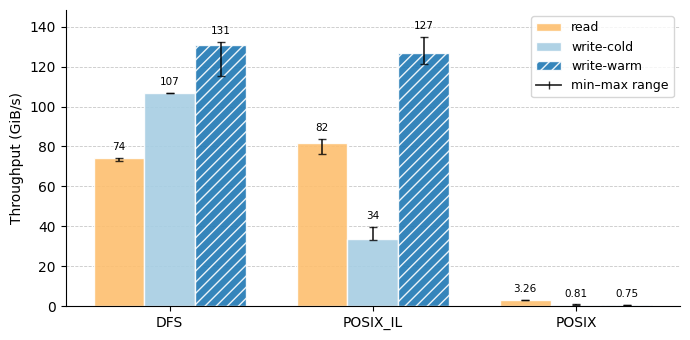

In [7]:
paired = sns.color_palette("Paired", 12)
COLORS = {"read": paired[6], "write-cold": paired[0], "write-warm": paired[1]}
HATCH  = {"write-cold": "", "write-warm": "///"}

x = np.arange(len(CONFIG_ORDER))
bar_w = 0.25
offsets = np.linspace(-(len(SERIES_ORDER) - 1) / 2, (len(SERIES_ORDER) - 1) / 2, len(SERIES_ORDER)) * bar_w

fig, ax = plt.subplots(figsize=(7, 3.5))

for xi, cfg in zip(x, CONFIG_ORDER):
    sub_cfg = combined[combined["config"] == cfg]
    for offset, series in zip(offsets, SERIES_ORDER):
        vals = sub_cfg.loc[sub_cfg["series"] == series, "bw_MiB_s"].to_numpy() / 1024
        if len(vals) == 0:
            continue
        xpos = xi + offset
        median = np.median(vals)
        vmin, vmax = vals.min(), vals.max()
        ax.bar(xpos, median, width=bar_w, color=COLORS[series], hatch=HATCH.get(series, ""),
               edgecolor="white", alpha=0.9, zorder=2, label=series if xi == 0 else None)
        ax.errorbar(xpos, median, yerr=[[median - vmin], [vmax - median]],
                    fmt="none", ecolor="black", capsize=3, linewidth=1.3, alpha=0.8, zorder=3)

        fmt = f"{median:.2f}" if median < 10 else f"{median:.0f}"
        ax.annotate(fmt, xy=(xpos, vmax), xytext=(0, 4),
                    textcoords="offset points", ha="center", va="bottom",
                    fontsize=7.5, color="black", rotation=0)

ax.set_xticks(x)
ax.set_xticklabels(CONFIG_ORDER, fontsize=10)
ax.set_ylabel("Throughput (GiB/s)")
ax.margins(y=0.1)

from matplotlib.lines import Line2D
eb_handle = Line2D([0], [0], color="black", linewidth=1.3, alpha=0.8,
                   marker="|", markersize=6, label="min–max range")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [eb_handle], labels + ["min–max range"], fontsize=9)

ax.yaxis.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
ax.yaxis.grid(True, which="minor", linestyle="--", linewidth=0.3, alpha=0.3)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.savefig("ior_rw_3modes_throughput.pdf", bbox_inches="tight")
plt.show()

## Throughput Comparison — Read vs Write-Cold vs Write-Warm, per Engine (Cache-On)

Same layout as above, but for the OS-page-cache-enabled (`cache == "cache"`)
runs, using the full `combined_all` frame captured before the nocache filter.

A fourth bar, **fio-write**, is added at each config using `fio --rw=randwrite`
results from `../../fio/engine` (`bs=1m`, `numjobs=16`, `iodepth=16`, 60s runs):
`fio_dfs` → `DFS`, `fio_libioil_pvsync2` → `POSIX_IL`, `fio_dfuse_pvsync2` →
`POSIX`. This is a different tool/access-pattern (random write, not sequential),
so it's a reference point rather than a like-for-like comparison with the IOR
series.

Loaded fio rand_write runs/config: {'DFS': 10, 'POSIX_IL': 20, 'POSIX': 12}


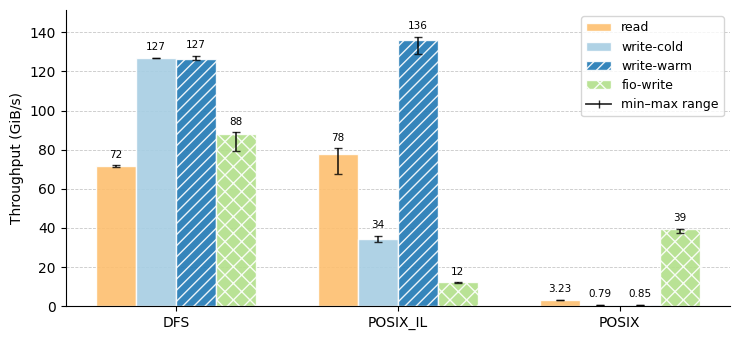

In [8]:
combined_cache = combined_all[combined_all["cache"] == "cache"].copy()

FIO_DIR = Path("../../fio/engine")
FIO_GLOBS = {
    "DFS":      "fio_dfs_*.json",
    "POSIX_IL": "fio_libioil_pvsync2_*.json",
    "POSIX":    "fio_dfuse_pvsync2_*.json",
}

def parse_fio_write_bw_MiB_s(fpath):
    text = Path(fpath).read_text()
    d = json.loads(text[text.find("{"):])
    return d["jobs"][0]["write"]["bw_bytes"] / 1024**2  # bytes/s -> MiB/s

fio_bw = {
    cfg: np.array([parse_fio_write_bw_MiB_s(f) for f in sorted(FIO_DIR.glob(pattern))])
    for cfg, pattern in FIO_GLOBS.items()
}
print(f"Loaded fio rand_write runs/config: { {cfg: len(v) for cfg, v in fio_bw.items()} }")

BAR_SERIES = SERIES_ORDER + ["fio-write"]

paired = sns.color_palette("Paired", 12)
COLORS = {"read": paired[6], "write-cold": paired[0], "write-warm": paired[1], "fio-write": paired[2]}
HATCH  = {"write-cold": "", "write-warm": "///", "fio-write": "xx"}

x = np.arange(len(CONFIG_ORDER))
bar_w = 0.18
offsets = np.linspace(-(len(BAR_SERIES) - 1) / 2, (len(BAR_SERIES) - 1) / 2, len(BAR_SERIES)) * bar_w

fig, ax = plt.subplots(figsize=(7.5, 3.5))

for xi, cfg in zip(x, CONFIG_ORDER):
    sub_cfg = combined_cache[combined_cache["config"] == cfg]
    for offset, series in zip(offsets, BAR_SERIES):
        vals = (fio_bw[cfg] if series == "fio-write"
                else sub_cfg.loc[sub_cfg["series"] == series, "bw_MiB_s"].to_numpy()) / 1024
        if len(vals) == 0:
            continue
        xpos = xi + offset
        median = np.median(vals)
        vmin, vmax = vals.min(), vals.max()
        ax.bar(xpos, median, width=bar_w, color=COLORS[series], hatch=HATCH.get(series, ""),
               edgecolor="white", alpha=0.9, zorder=2, label=series if xi == 0 else None)
        ax.errorbar(xpos, median, yerr=[[median - vmin], [vmax - median]],
                    fmt="none", ecolor="black", capsize=3, linewidth=1.3, alpha=0.8, zorder=3)

        fmt = f"{median:.2f}" if median < 10 else f"{median:.0f}"
        ax.annotate(fmt, xy=(xpos, vmax), xytext=(0, 4),
                    textcoords="offset points", ha="center", va="bottom",
                    fontsize=7.5, color="black", rotation=0)

ax.set_xticks(x)
ax.set_xticklabels(CONFIG_ORDER, fontsize=10)
ax.set_ylabel("Throughput (GiB/s)")
ax.margins(y=0.1)

from matplotlib.lines import Line2D
eb_handle = Line2D([0], [0], color="black", linewidth=1.3, alpha=0.8,
                   marker="|", markersize=6, label="min–max range")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [eb_handle], labels + ["min–max range"], fontsize=9)

ax.yaxis.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
ax.yaxis.grid(True, which="minor", linestyle="--", linewidth=0.3, alpha=0.3)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.savefig("ior_rw_3modes_throughput_cache.pdf", bbox_inches="tight")
plt.show()

## Sanity Check — Does `Latency` x Transfer Count Reconcile with `wr/rd(s)`?

IOR was run with `-s 32` (segments), `-b 128M` (block size), `-t 2M` (transfer
size) — `-s` isn't a column in the CSV, so it's hardcoded below from the
launch script (`scripts/aurora/ior/run_ior_rw_3modes.sh`). Each task does
`block(KiB)/xfer(KiB) = 64` transfers per segment, x 32 segments = **2048
transfers/task/iteration** (98,304 across all 48 tasks) — confirmed
separately by cross-checking `bw(MiB/s) x wr/rd(s)` against `block(KiB) x
segments` per task (matches to <1%, i.e. the full segment-multiplied byte
count really was moved).

Naively, `Latency x (transfers/task)` should reconstruct `wr/rd(s)`. It
doesn't: `Latency x 2048` overshoots `wr/rd(s)` by a near-constant ~31-32x
(suspiciously close to the segment count, 32) for every `(engine, cache,
series)` except `write-cold`, where lock-contention on open inflates
`wr/rd(s)` itself (see phase-breakdown section above). `Latency x 64`
(transfers *per segment*, ignoring the x32 segment multiplier) reconciles
with `wr/rd(s)` to within 1-3% instead. IOR's own `Latency` field therefore
behaves like an average over one segment's worth of transfers (64), not the
full per-task transfer count — a quirk of IOR's internal accounting (IOR
v4.0.0; not something this repo post-processes), not a data-collection bug
here.</cell id="placeholder">

In [30]:
lat_check = combined_all[combined_all["engine"].isin(CONFIG_ORDER)].copy()
lat_check["n_transfers_per_segment"] = lat_check["block(KiB)"] / lat_check["xfer(KiB)"]
lat_check["n_transfers_per_task"] = lat_check["n_transfers_per_segment"] * lat_check["segments"]

lat_check["latency_x_segment"] = lat_check["Latency"] * lat_check["n_transfers_per_segment"]
lat_check["latency_x_task"]    = lat_check["Latency"] * lat_check["n_transfers_per_task"]
lat_check["ratio_segment"] = lat_check["latency_x_segment"] / lat_check["wr/rd(s)"]
lat_check["ratio_task"]    = lat_check["latency_x_task"] / lat_check["wr/rd(s)"]

lat_summary = (
    lat_check.groupby(["engine", "cache", "series"])
    .agg(
        wr_rd_s=("wr/rd(s)", "mean"),
        Latency_s=("Latency", "mean"),
        latency_x_64=("latency_x_segment", "mean"),
        ratio_x_64=("ratio_segment", "mean"),
        latency_x_2048=("latency_x_task", "mean"),
        ratio_x_2048=("ratio_task", "mean"),
        n=("Latency", "count"),
    )
    .reset_index()
)
lat_summary["engine"] = pd.Categorical(lat_summary["engine"], CONFIG_ORDER, ordered=True)
lat_summary["series"] = pd.Categorical(lat_summary["series"], SERIES_ORDER, ordered=True)
lat_summary = lat_summary.sort_values(["engine", "cache", "series"])

display(
    lat_summary.style.format({
        "wr_rd_s": "{:.3f}", "Latency_s": "{:.4f}",
        "latency_x_64": "{:.3f}", "ratio_x_64": "{:.3f}x",
        "latency_x_2048": "{:.2f}", "ratio_x_2048": "{:.1f}x",
    })
    .set_caption("wr/rd(s) vs Latency x transfer-count, per engine x cache x series")
    .hide(axis="index")
)

engine,cache,series,wr_rd_s,Latency_s,latency_x_64,ratio_x_64,latency_x_2048,ratio_x_2048,n
DFS,cache,read,2.673,0.0416,2.664,0.997x,85.26,31.9x,10
DFS,cache,write-cold,1.511,0.0236,1.510,1.000x,48.33,32.0x,1
DFS,cache,write-warm,1.513,0.0236,1.509,0.997x,48.29,31.9x,9
DFS,nocache,read,2.592,0.0402,2.573,0.993x,82.35,31.8x,10
DFS,nocache,write-cold,1.795,0.0231,1.478,0.824x,47.31,26.4x,1
DFS,nocache,write-warm,1.502,0.0227,1.454,0.969x,46.51,31.0x,9
POSIX_IL,cache,read,2.531,0.0376,2.407,0.954x,77.02,30.5x,14
POSIX_IL,cache,write-cold,5.607,0.0233,1.494,0.267x,47.82,8.5x,4
POSIX_IL,cache,write-warm,1.424,0.0218,1.396,0.981x,44.69,31.4x,10
POSIX_IL,nocache,read,2.358,0.0352,2.255,0.958x,72.16,30.7x,11


## Transfer Time vs Meta-Operation Time -- DFS & POSIX_IL, Cache Off

Using the `Latency x 64` reconciliation confirmed above, split each
iteration's `total(s)` into:

- **transfer time** = `Latency x 64` -- time actually moving the 64
  transfers/segment that IOR's `Latency` field averages over.
- **meta time** = `total(s) - transfer time` -- everything else per
  iteration (open/close, bookkeeping, etc).

Stacked bars (mean per group, so the two segments sum exactly to mean
`total(s)`), cache-off only, 1x2 panels for `DFS` / `POSIX_IL`; x-axis =
read / write-cold / write-warm within each panel. Value labels are shown
for transfer time and the total (wall) time only -- meta time is left
unlabeled since it's a derived remainder, not a directly measured
quantity. Black whiskers mark the min-max range of `total(s)` per group.
`POSIX` (dfuse) is excluded here -- it's ~100x slower and would dominate
the y-axis.

In [ ]:
combined_all["transfer_time_s"] = combined_all["latency_s"] * 64
combined_all["meta_time_s"] = combined_all["walltime_s"] - combined_all["transfer_time_s"]

TIME_ENGINES = ["DFS", "POSIX_IL"]
CACHE = "nocache"

time_stats = (
    combined_all[combined_all["engine"].isin(TIME_ENGINES) & (combined_all["cache"] == CACHE)]
    .groupby(["engine", "series"])
    .agg(
        transfer_time_s=("transfer_time_s", "median"),
        meta_time_s=("meta_time_s", "median"),
        total_min_s=("walltime_s", "min"),
        total_max_s=("walltime_s", "max"),
    )
    .reset_index()
)

tab10 = sns.color_palette("tab10")
TRANSFER_COLOR, META_COLOR = tab10[0], tab10[1]

from matplotlib.lines import Line2D

x = np.arange(len(SERIES_ORDER))
bar_w = 0.5

fig, axes = plt.subplots(1, len(TIME_ENGINES), figsize=(8, 3), sharey=True)

for col_i, engine in enumerate(TIME_ENGINES):
    ax = axes[col_i]
    row_src = (
        time_stats[time_stats["engine"] == engine]
        .set_index("series")
        .reindex(SERIES_ORDER)
    )
    transfer_vals = row_src["transfer_time_s"]
    meta_vals = row_src["meta_time_s"]
    total_vals = transfer_vals + meta_vals
    total_min = row_src["total_min_s"]
    total_max = row_src["total_max_s"]

    ax.bar(x, transfer_vals, width=bar_w, color=TRANSFER_COLOR,
           edgecolor="white", zorder=2,
           label="transfer time" if col_i == 0 else None)
    ax.bar(x, meta_vals, width=bar_w, bottom=transfer_vals,
           color=META_COLOR, edgecolor="white", zorder=2,
           label="meta time" if col_i == 0 else None)
    ax.errorbar(x, total_vals, yerr=[total_vals - total_min, total_max - total_vals],
                fmt="none", ecolor="black", capsize=3, linewidth=1.3, alpha=0.8, zorder=4)

    for xi, tv, tot, tmax in zip(x, transfer_vals, total_vals, total_max):
        if np.isnan(tot):
            continue
        ax.annotate(f"{tv:.2f}", xy=(xi, tv / 2), ha="center", va="center",
                    fontsize=7, color="white", zorder=5)
        ax.annotate(f"{tot:.2f}", xy=(xi, tmax), xytext=(0, 4),
                    textcoords="offset points", ha="center", va="bottom",
                    fontsize=10, fontweight="bold", zorder=5)

    ax.set_xticks(x)
    ax.set_xticklabels(SERIES_ORDER, fontsize=9)
    engine_label = "POSIX" if engine == "POSIX_IL" else engine
    ax.text(0.95, 0.95, engine_label, transform=ax.transAxes, ha="right", va="top",
            fontsize=12, fontweight="bold")
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Time per iteration (s)")
axes[0].margins(y=0.05)

eb_handle = Line2D([0], [0], color="black", linewidth=1.3, alpha=0.8,
                    marker="|", markersize=6, label="min–max range")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles + [eb_handle], labels + ["min–max range"], loc="upper center",
           bbox_to_anchor=(0.18, 0.9), ncol=1, fontsize=10, framealpha=0.8,
           bbox_transform=fig.transFigure)

# fig.suptitle("Cache Off", fontsize=11, y=1.2)
fig.tight_layout()
plt.savefig("ior_rw_time-nocache.pdf", bbox_inches="tight")
plt.show()